# Customer Churn Prediction & Customer Segmentation

## 04 — Model Development & Comparison

### Objective

The data is now prepared for machine learning.

In this notebook we will answer:

> **Which classification model gives us the most useful churn predictions for the business?**

We will follow a controlled modelling process:

1. Load and prepare the modelling data.
2. Establish a simple baseline.
3. Train a small set of suitable classification models.
4. Evaluate them using business-relevant metrics.
5. Compare their performance.
6. Select an initial candidate for deeper evaluation.

We are not trying to maximize accuracy blindly.

For churn prediction, we will pay attention to:

- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion matrix

> **Model selection is evidence-driven.**

## 1. Import libraries

We use Scikit-learn for the modelling workflow and a small set of strong tabular classification models.

We are deliberately not training every classifier available. The goal is a useful comparison, not a leaderboard.

In [1]:
from pathlib import Path

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## 2. Define project paths

The raw dataset remains the source of truth.

For this notebook, we reproduce the preparation logic from `03_data_preparation.ipynb` so that the modelling experiment is reproducible on its own.

Later, the reusable preparation logic will move into `src/`.

In [2]:
PROJECT_ROOT = Path.cwd().parent

RAW_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "Customer-Churn.csv"
)

MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:", PROJECT_ROOT)
print("Raw dataset:", RAW_DATA_PATH)

Project root: d:\Projects\Customer Churn Segmentation
Raw dataset: d:\Projects\Customer Churn Segmentation\data\raw\Customer-Churn.csv


## 3. Load and prepare the modelling data

We apply the same cleaning and feature-engineering decisions made in the previous notebook.

The important thing is consistency: the model should receive the same type of features that were defined during preparation.

In [3]:
if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset was not found at: {RAW_DATA_PATH}"
    )

df = pd.read_csv(RAW_DATA_PATH)

working_df = df.copy()

print(
    f"Raw dataset loaded: "
    f"{working_df.shape[0]:,} rows × {working_df.shape[1]} columns"
)

Raw dataset loaded: 7,043 rows × 21 columns


In [4]:
# Convert TotalCharges from text to numeric.

total_charges_numeric = pd.to_numeric(
    working_df["TotalCharges"].astype(str).str.strip(),
    errors="coerce"
)

missing_total_charges = total_charges_numeric.isnull()

working_df["TotalCharges"] = total_charges_numeric

# Reconstruct the few invalid values using
# tenure × monthly charges.

working_df.loc[
    missing_total_charges,
    "TotalCharges"
] = (
    working_df.loc[
        missing_total_charges,
        "tenure"
    ]
    * working_df.loc[
        missing_total_charges,
        "MonthlyCharges"
    ]
)

In [5]:
# Feature 1: approximate historical monthly spending.

working_df["AverageMonthlySpend"] = (
    working_df["TotalCharges"]
    / working_df["tenure"].clip(lower=1)
)

# Feature 2: early-lifecycle indicator.

working_df["IsNewCustomer"] = (
    working_df["tenure"] <= 12
).astype(int)

# Feature 3: number of optional services.

service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

working_df["ServiceCount"] = 0

for column in service_columns:
    working_df["ServiceCount"] += (
        working_df[column] == "Yes"
    ).astype(int)

In [6]:
# Keep customer IDs separately for traceability.
customer_ids = working_df["customerID"].copy()

# Do not use customerID as a predictive feature.
working_df = working_df.drop(
    columns=["customerID"]
)

# Encode the target.
working_df["Churn"] = (
    working_df["Churn"]
    .map({
        "No": 0,
        "Yes": 1
    })
)

X = working_df.drop(
    columns=["Churn"]
)

y = working_df["Churn"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (7043, 22)
Target shape: (7043,)


## 4. Identify feature types

Numerical and categorical features require different preprocessing.

We will scale numerical variables and one-hot encode categorical variables.

In [7]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
for column in numerical_features:
    print(f"- {column}")

print()
print("Categorical features:")
for column in categorical_features:
    print(f"- {column}")

Numerical features:
- SeniorCitizen
- tenure
- MonthlyCharges
- TotalCharges
- AverageMonthlySpend
- IsNewCustomer
- ServiceCount

Categorical features:
- gender
- Partner
- Dependents
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- Contract
- PaperlessBilling
- PaymentMethod


C:\Users\Aman\AppData\Local\Temp\ipykernel_15504\3355591494.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


## 5. Train/test split

We split the data before fitting the preprocessing pipeline.

This prevents information from the test set from influencing preprocessing parameters.

`stratify=y` keeps the churn proportion approximately consistent across both sets.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")

Training rows: 5,634
Test rows: 1,409


In [9]:
print("Training target distribution:")
display(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_frame("Percentage")
)

print("Test target distribution:")
display(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_frame("Percentage")
)

Training target distribution:


,Percentage
Churn,
0,73.46
1,26.54


Test target distribution:


,Percentage
Churn,
0,73.46
1,26.54


## 6. Build the preprocessing pipeline

The same preprocessing rules must be applied consistently during training, evaluation, and eventually production inference.

We use:

- `StandardScaler` for numerical features
- `OneHotEncoder` for categorical features
- `handle_unknown="ignore"` so unseen categories do not crash inference

In [10]:
numerical_preprocessor = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        (
            "one_hot_encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_preprocessor,
            numerical_features
        ),
        (
            "categorical",
            categorical_preprocessor,
            categorical_features
        )
    ]
)

preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing fitted on training data only.")
print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Preprocessing fitted on training data only.
Processed training shape: (5634, 48)
Processed test shape: (1409, 48)


# Part A — Baseline

## 7. Establish a naive baseline

A model should beat a simple strategy.

Because churn is the minority class, predicting the majority class for every customer can produce a seemingly high accuracy while detecting no churners.

This is why we establish the baseline first.

In [11]:
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(
    X_train_processed,
    y_train
)

baseline_predictions = baseline_model.predict(
    X_test_processed
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Baseline recall:   {baseline_recall:.4f}")

Baseline accuracy: 0.7346
Baseline recall:   0.0000


### Baseline interpretation

The baseline is useful because it shows what we would get without learning any meaningful relationship from the features.

Our actual models should improve substantially on its ability to identify churners.

# Part B — Candidate models

## 8. Define the models

We will compare five models:

**Logistic Regression** — simple, interpretable linear baseline.

**Decision Tree** — captures non-linear rules but can overfit.

**Random Forest** — ensemble of decision trees.

**XGBoost** — gradient boosting model that is strong on structured/tabular data.

**CatBoost** — another strong boosting approach for tabular problems.

We start with reasonable configurations rather than performing large-scale hyperparameter searches immediately.

In [12]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        verbose=False,
        random_seed=42
    )
}

for model_name in models:
    print(f"- {model_name}")

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- CatBoost


# Part C — Train and evaluate

## 9. Create one consistent evaluation function

Every candidate model should be evaluated using the same metrics and the same test data.

This prevents us from changing the evaluation rules from model to model.

In [13]:
def evaluate_model(
    model,
    X_train_data,
    y_train_data,
    X_test_data,
    y_test_data
):
    # Train the model.
    model.fit(
        X_train_data,
        y_train_data
    )

    # Generate class predictions.
    predictions = model.predict(
        X_test_data
    )

    # Generate probability of churn.
    probabilities = model.predict_proba(
        X_test_data
    )[:, 1]

    # Calculate business-relevant classification metrics.
    results = {
        "Accuracy": accuracy_score(
            y_test_data,
            predictions
        ),
        "Precision": precision_score(
            y_test_data,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_data,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test_data,
            predictions,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_test_data,
            probabilities
        )
    }

    return results, predictions, probabilities

## 10. Train all candidate models

All models use the same training/test split and the same processed features.

This makes the comparison fair.

In [14]:
model_results = {}

trained_models = {}

model_predictions = {}

model_probabilities = {}

for model_name, model in models.items():

    print(f"Training {model_name}...")

    results, predictions, probabilities = evaluate_model(
        model,
        X_train_processed,
        y_train,
        X_test_processed,
        y_test
    )

    model_results[model_name] = results
    trained_models[model_name] = model
    model_predictions[model_name] = predictions
    model_probabilities[model_name] = probabilities

print("All candidate models have been trained.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training CatBoost...
All candidate models have been trained.


## 11. Compare model performance

The table below provides the first evidence for model selection.

In [15]:
model_comparison = pd.DataFrame(
    model_results
).T

model_comparison = model_comparison.sort_values(
    by="F1",
    ascending=False
)

model_comparison.round(4)

,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.8048,0.6645,0.5348,0.5926,0.8417
CatBoost,0.8027,0.6655,0.5160,0.5813,0.8412
XGBoost,0.7956,0.6483,0.5027,0.5663,0.8413
Random Forest,0.7899,0.6327,0.4973,0.5569,0.8318
Decision Tree,0.7899,0.6364,0.4866,0.5515,0.8340


### Metric interpretation

**Precision:** Of the customers we flag as likely churners, how many actually churn?

**Recall:** Of all customers who actually churn, how many did we identify?

**F1-score:** Balance between precision and recall.

**ROC-AUC:** How well the model ranks churners above non-churners across possible thresholds.

**Accuracy:** Overall correctness, but not sufficient by itself for this problem.

# Part D — Initial candidate selection

## 12. Select the strongest initial candidate

For the first comparison, we use F1-score as a balanced screening criterion.

This is **not** the final business decision.

Later we will examine threshold choice and the relative cost of false negatives and false positives.

In [16]:
best_model_name = model_comparison["F1"].idxmax()

best_model = trained_models[
    best_model_name
]

best_predictions = model_predictions[
    best_model_name
]

best_probabilities = model_probabilities[
    best_model_name
]

print(
    "Initial best candidate:",
    best_model_name
)

Initial best candidate: Logistic Regression


## 13. Confusion matrix

The confusion matrix lets us see exactly how the selected candidate is making mistakes.

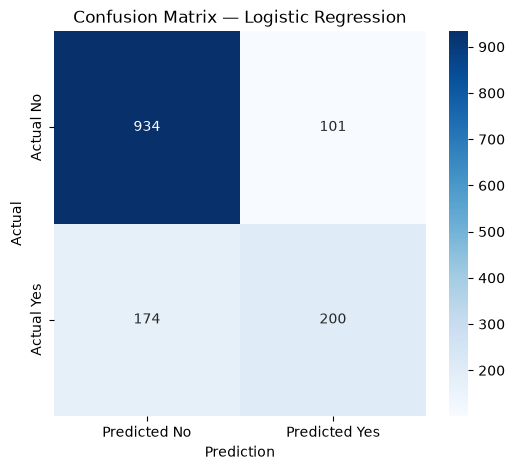

In [17]:
confusion = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted No",
        "Predicted Yes"
    ],
    yticklabels=[
        "Actual No",
        "Actual Yes"
    ]
)

plt.title(
    f"Confusion Matrix — {best_model_name}"
)

plt.xlabel("Prediction")
plt.ylabel("Actual")

plt.show()

### Business interpretation

The most important error for a retention system may be a **false negative**:

> The customer actually churns, but the model fails to flag them.

A false positive also has a cost because the business may spend retention resources on a customer who would have stayed.

This trade-off is why we will not blindly accept the default probability threshold of 0.50.

## 14. Classification report

Let's inspect the detailed performance for the initial candidate.

In [18]:
print(
    classification_report(
        y_test,
        best_predictions,
        target_names=[
            "No Churn",
            "Churn"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



# Part E — Visual model comparison

## 15. Compare Precision, Recall and F1

The visual comparison helps us see where models trade precision for recall.

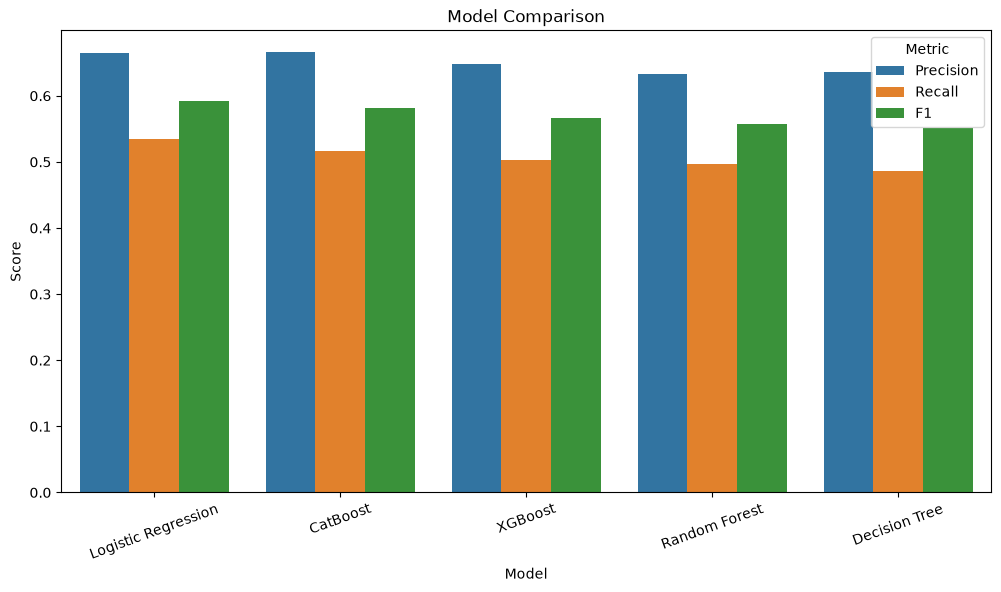

In [19]:
metrics_to_plot = [
    "Precision",
    "Recall",
    "F1"
]

plot_data = (
    model_comparison[
        metrics_to_plot
    ]
    .reset_index()
    .rename(columns={"index": "Model"})
)

plot_data = plot_data.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=plot_data,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=20)

plt.show()

# 16. Model development conclusion

### Completed

- Built a naive baseline.
- Compared five classification models.
- Used the same train/test split for all models.
- Evaluated precision, recall, F1 and ROC-AUC.
- Inspected the confusion matrix.
- Identified an initial strongest candidate.

### Not final yet

The model has **not** been declared production-ready.

The default 0.50 probability threshold is only a starting point.

The next stage must answer:

> **What probability threshold gives the business the best trade-off between catching churners and spending retention resources?**

We also need:

- threshold analysis
- error analysis
- feature importance
- explainability
- final validation

### Next notebook

**05 — Model Evaluation, Threshold Optimization & Explainability**

> The final goal is not simply to build a model with a high score. It is to build a reliable churn-risk decision system that the business can actually use.